# Model Training - XGBoost

This notebook trains and evaluates an XGBoost classifier for employee attrition prediction.

The workflow includes:

- Baseline model training
- Model evaluation
- Cross-validation
- Hyperparameter optimization
- Feature importance analysis
- Saving the final model for deployment

In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

import joblib

from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(
    "../data/processed/hr_feature_engineered.csv"
)

print(df.shape)

df.head()

(1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [9]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print(X.shape)
print(y.shape)

(1470, 30)
(1470,)


In [13]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

# Features
X = df.drop("Attrition", axis=1)

# Target
y = df["Attrition"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1176, 30)
X_test : (294, 30)
y_train: (1176,)
y_test : (294,)


In [16]:
# ==========================================================
# BASELINE XGBOOST MODEL
# ==========================================================

baseline_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train the model
baseline_model.fit(X_train, y_train)

# Predictions
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8469387755102041
Precision: 0.5555555555555556
Recall   : 0.2127659574468085
F1 Score : 0.3076923076923077
ROC AUC  : 0.7580325609440951


## Model Evaluation

The baseline XGBoost classifier was evaluated on the test dataset using several classification metrics to assess its predictive performance.

### Evaluation Metrics

| Metric | Score |
|--------|------:|
| Accuracy | 84.69% |
| Precision | 55.56% |
| Recall | 21.28% |
| F1-Score | 30.77% |
| ROC-AUC | 0.758 |

### Interpretation

The model achieved an accuracy of **84.69%**, indicating good overall classification performance. However, the **recall (21.28%)** is relatively low, meaning that the model correctly identifies only a small proportion of employees who actually leave the company. The **ROC-AUC score of 0.758** suggests that the model has a reasonable ability to distinguish between employees who leave and those who remain.

These results serve as a **baseline model**. Further improvements, such as hyperparameter tuning, cross-validation, and handling class imbalance, can be applied to improve recall and overall predictive performance.

## Model Visualization

To better understand the model's performance and interpretability, the following visualizations were generated:

- Confusion Matrix
- ROC Curve
- Feature Importance

<Figure size 600x500 with 0 Axes>

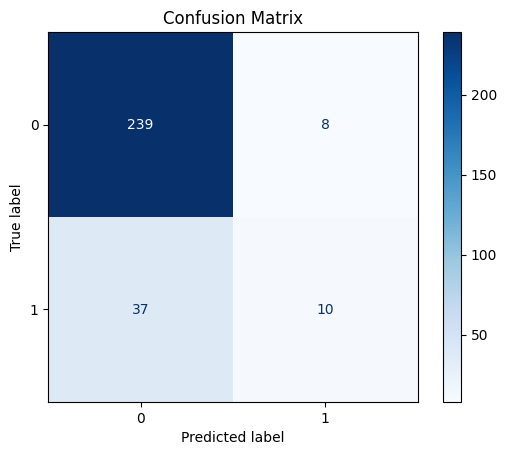

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

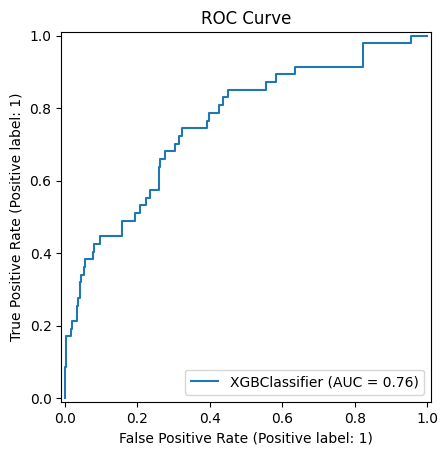

In [36]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(6,5))

RocCurveDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

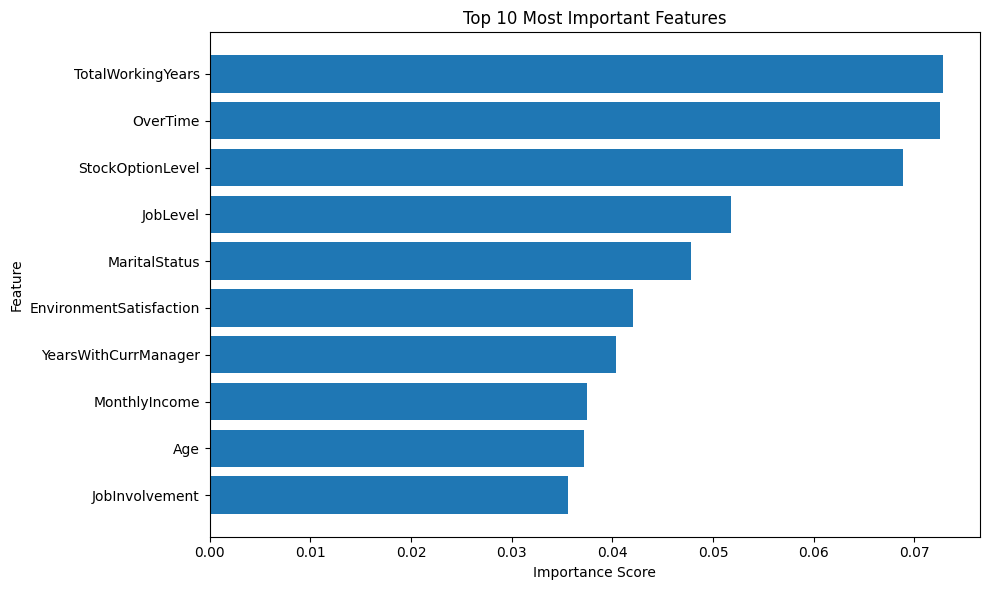

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": baseline_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Cross Validation

5-fold cross-validation is performed to estimate model stability across different data splits.

In [38]:
# ==========================================================
# CROSS VALIDATION
# ==========================================================

cv_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("CV Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

CV Scores: [0.81698848 0.77227304 0.79636489 0.79007666 0.84477561]
Mean ROC-AUC: 0.8040957353431748


## Hyperparameter Optimization

RandomizedSearchCV is used to identify the best combination of XGBoost hyperparameters.

In [39]:
# ==========================================================
# HYPERPARAMETER TUNING
# ==========================================================

param_grid = {

    "max_depth": [3,4,5,6],

    "learning_rate": [
        0.01,
        0.05,
        0.1
    ],

    "n_estimators": [
        100,
        200,
        300
    ],

    "subsample": [
        0.8,
        1.0
    ],

    "colsample_bytree": [
        0.8,
        1.0
    ],

    "gamma": [
        0,
        0.1,
        0.3
    ]
}


search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)


search.fit(
    X_train,
    y_train
)


print(search.best_params_)
print(search.best_score_)

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
0.8061094514474156


In [40]:
best_model = search.best_estimator_

Accuracy : 0.8673469387755102
Precision: 0.7857142857142857
Recall   : 0.23404255319148937
F1 Score : 0.36065573770491804
ROC AUC  : 0.7799121371349814


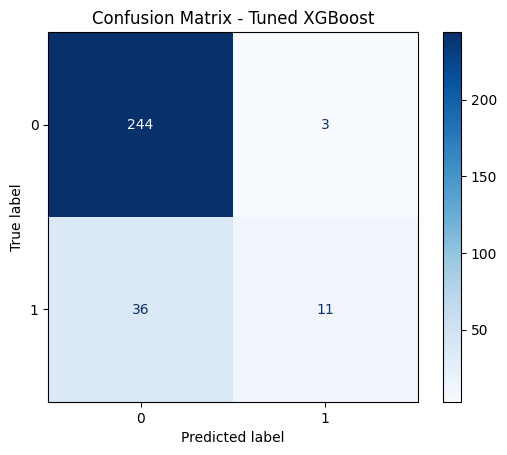

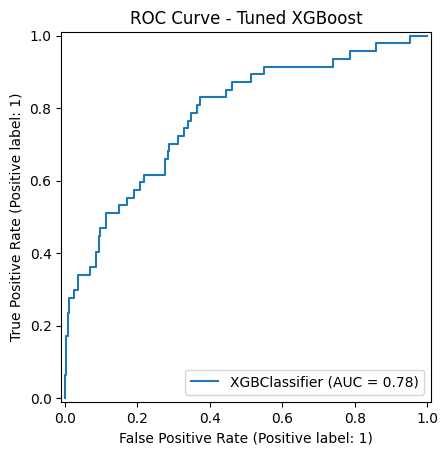

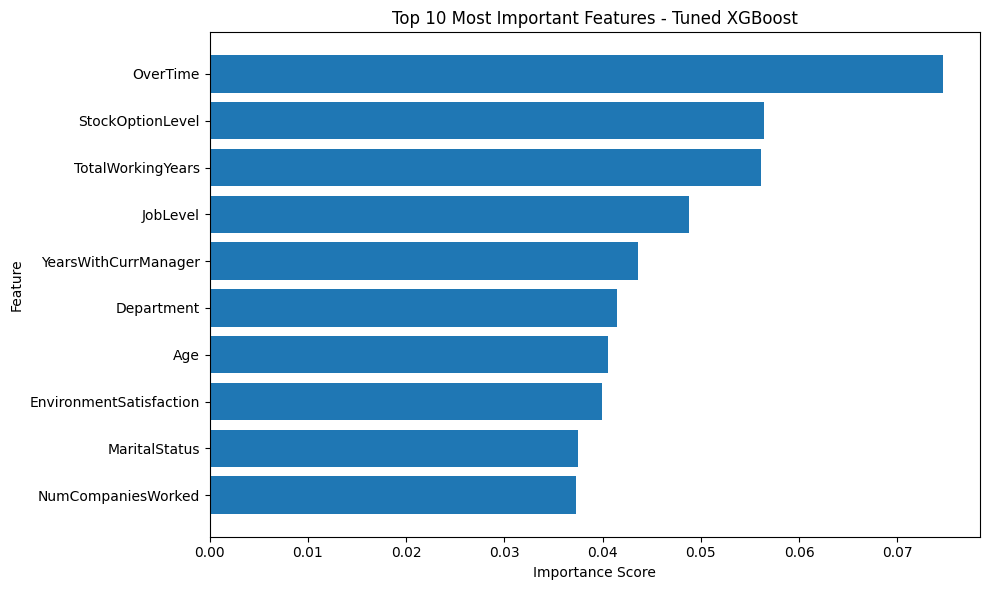

In [44]:
# ============================================================
# TUNED XGBOOST MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
import pandas as pd

# Train the best model (optional, but makes the workflow explicit)
best_model.fit(X_train, y_train)

# Predictions
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# ============================================================
# Evaluation Metrics
# ============================================================

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best))

# ============================================================
# Confusion Matrix
# ============================================================

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

# ============================================================
# ROC Curve
# ============================================================

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Tuned XGBoost")
plt.show()

# ============================================================
# Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - Tuned XGBoost")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [45]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10)

OverTime                   0.074685
StockOptionLevel           0.056393
TotalWorkingYears          0.056167
JobLevel                   0.048785
YearsWithCurrManager       0.043619
Department                 0.041473
Age                        0.040532
EnvironmentSatisfaction    0.039965
MaritalStatus              0.037530
NumCompaniesWorked         0.037332
dtype: float32

In [47]:
# ==========================================================
# SAVE FINAL XGBOOST MODEL
# ==========================================================

import joblib

joblib.dump(
    best_model,
    "../models/xgboost_final_model.pkl"
)

print("Final optimized XGBoost model saved successfully!")

Final optimized XGBoost model saved successfully!


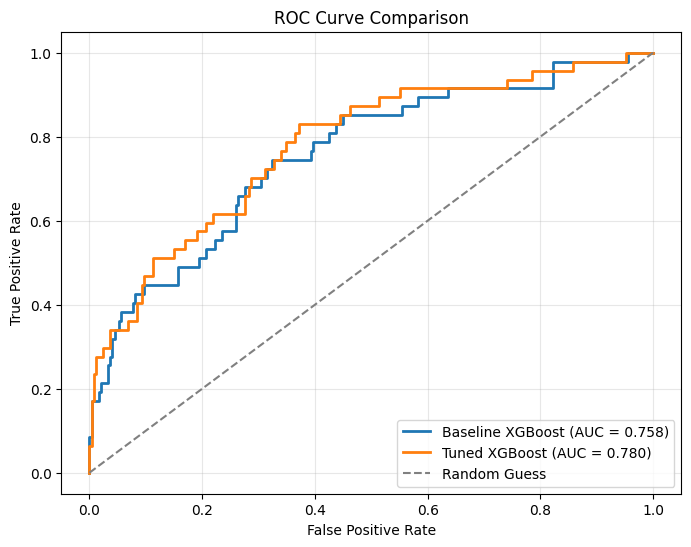

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Baseline ROC
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob)
auc_base = auc(fpr_base, tpr_base)

# Tuned ROC
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
auc_best = auc(fpr_best, tpr_best)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr_base,
    tpr_base,
    linewidth=2,
    label=f"Baseline XGBoost (AUC = {auc_base:.3f})"
)

plt.plot(
    fpr_best,
    tpr_best,
    linewidth=2,
    label=f"Tuned XGBoost (AUC = {auc_best:.3f})"
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

## ROC Curve Comparison

The ROC curves compare the baseline XGBoost model with the optimized model obtained through hyperparameter tuning.

The tuned model achieved a higher ROC-AUC score (**0.780**) compared with the baseline model (**0.758**), indicating an improved ability to distinguish employees who are likely to leave from those who are likely to stay.

Although the improvement is modest, it demonstrates that hyperparameter tuning enhanced the model's discriminative performance.